<a href="https://colab.research.google.com/github/Soljafree60/git-work/blob/main/03_PINN_Black_Scholes_Clean_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics-Informed Neural Network for the Black–Scholes PDE

PINN of the project.

The model solves the European call Black–Scholes PDE

$$
V_t+\frac{1}{2}\sigma^2S^2V_{SS}+rSV_S-rV=0
$$

subject to

$$
V(0,t)=0,
$$

$$
V(S_{\max},t)=S_{\max}-Ke^{-r(T-t)},
$$

and

$$
V(S,T)=\max(S-K,0).
$$

To improve PINN training, the network predicts the **normalised option price**

$$
u(S,t)=\frac{V(S,t)}{K}.
$$

Because $V=Ku$, the PDE retains the same form:

$$
u_t+\frac{1}{2}\sigma^2S^2u_{SS}+rSu_S-ru=0.
$$

The analytical Black–Scholes solution is used **only for validation after training**, not as labelled training data.


## 1. Imports and reproducibility


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import time

from scipy.stats import norm

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Use float32 consistently
tf.keras.backend.set_floatx("float32")

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)


TensorFlow version: 2.20.0
NumPy version: 2.1.3


### Libraries used

NumPy is used for numerical arrays and mathematical operations (Harris et al., 2020), pandas is used to organise numerical outputs into tables (McKinney, 2010), Matplotlib is used for figures (Hunter, 2007), SciPy provides established numerical routines such as the normal distribution and banded linear-system solvers (Virtanen et al., 2020), and TensorFlow supplies automatic differentiation and neural-network optimisation required by the PINN formulation (Raissi et al., 2019).

A fixed random seed is used to improve reproducibility. This does not make every TensorFlow operation perfectly deterministic on every hardware configuration, but it reduces unnecessary variation between experimental runs.


## 2. Black–Scholes parameters and PINN hyperparameters


In [ ]:
# ============================================================
# BLACK-SCHOLES BASELINE PARAMETERS
# ============================================================

S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.20
T = 1.0
S_max = 200.0

# ============================================================
# PINN HYPERPARAMETERS
# ============================================================

N_f = 10_000   # Interior collocation points
N_b = 1_000    # Boundary points
N_T = 1_000    # Terminal points

LEARNING_RATE = 0.001

# Start with 1,000 for a diagnostic run.
# Once training behaviour is satisfactory, change to 10_000.
EPOCHS = 1_000

lambda_f = 1.0
lambda_B = 1.0
lambda_T = 1.0

print("Baseline parameters")
print("-------------------")
print("S0 =", S0)
print("K =", K)
print("r =", r)
print("sigma =", sigma)
print("T =", T)
print("S_max =", S_max)
print()
print("PINN hyperparameters")
print("--------------------")
print("N_f =", N_f)
print("N_b =", N_b)
print("N_T =", N_T)
print("Learning rate =", LEARNING_RATE)
print("Epochs =", EPOCHS)


Baseline parameters
-------------------
S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0
S_max = 200.0

PINN hyperparameters
--------------------
N_f = 10000
N_b = 1000
N_T = 1000
Learning rate = 0.001
Epochs = 1000


### Why I used these model parameters and hyperparameters

The Black–Scholes parameters define the financial problem being solved. The baseline values are held fixed unless the notebook is explicitly performing a sensitivity study. This produces a controlled reference case against which numerical changes can be measured (Black & Scholes, 1973; Hull, 2018).

The PINN hyperparameters define the computational budget and network training configuration. Keeping these settings explicit is important for reproducibility and makes it possible to distinguish changes in model accuracy caused by the market parameter from changes caused by the numerical procedure.


## 3. Analytical Black–Scholes solution for validation


In [ ]:
def black_scholes_call(S, K, r, sigma, T, t=0.0):
    """
    Analytical Black-Scholes price for a European call option.

    Handles:
    - S = 0 without evaluating log(0)
    - t = T by returning the terminal payoff
    """

    scalar_input = np.isscalar(S)
    S = np.asarray(S, dtype=float)

    tau = T - t

    # At maturity, return the payoff directly
    if tau <= 0:
        result = np.maximum(S - K, 0.0)
        return float(result) if scalar_input else result

    result = np.zeros_like(S, dtype=float)

    # Avoid log(0)
    positive = S > 0
    S_pos = S[positive]

    d1 = (
        np.log(S_pos / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))

    d2 = d1 - sigma * np.sqrt(tau)

    result[positive] = (
        S_pos * norm.cdf(d1)
        - K * np.exp(-r * tau) * norm.cdf(d2)
    )

    return float(result) if scalar_input else result


analytical_price = black_scholes_call(
    S0, K, r, sigma, T, t=0.0
)

print(f"Analytical Black-Scholes price at S={S0:.0f}, t=0: {analytical_price:.10f}")


Analytical Black-Scholes price at S=100, t=0: 10.4505835722


### Why I used the analytical Black–Scholes function

The analytical European call solution is used as the benchmark because the Black–Scholes model has a closed-form solution under the assumptions used in this study (Black & Scholes, 1973; Hull, 2018). This allowed the numerical FDM and PINN solutions to be evaluated against a known reference rather than against one another.

The implementation handles $S=0$ and maturity separately to avoid undefined expressions such as $\log(0)$ or division by zero. These are numerical safeguards; they do not alter the Black–Scholes model.


## 4. Input scaling

The physical variables have different scales:

$$
S\in[0,200],
\qquad
t\in[0,1].
$$

The neural-network inputs are therefore scaled to approximately $[-1,1]$.  
The derivatives used in the PDE are still taken with respect to the **physical variables** $S$ and $t$, because TensorFlow applies the chain rule through this scaling automatically.


In [ ]:
def scale_inputs(S, t):
    """
    Scale physical inputs S and t to approximately [-1, 1].
    """

    S_scaled = 2.0 * S / S_max - 1.0
    t_scaled = 2.0 * t / T - 1.0

    return S_scaled, t_scaled


def model_prediction(model, S, t):
    """
    Predict the normalised option price u(S,t) = V(S,t)/K.
    """

    S_scaled, t_scaled = scale_inputs(S, t)

    inputs = tf.concat(
        [S_scaled, t_scaled],
        axis=1
    )

    return model(inputs)


### Why I scaled the inputs

The asset price and time variables have different numerical ranges. Scaling them to approximately $[-1,1]$ improves the conditioning of the neural-network optimisation and is compatible with the use of `tanh` activation functions. PINNs are sensitive to optimisation and gradient behaviour, so numerical scaling can materially improve training stability (Karniadakis et al., 2021; Wang et al., 2021).

The PDE derivatives are still taken with respect to the physical variables $S$ and $t$. TensorFlow applies the chain rule through the scaling transformation automatically.


## 5. PINN architecture


In [ ]:
class PINN(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.hidden1 = tf.keras.layers.Dense(
            64,
            activation="tanh"
        )

        self.hidden2 = tf.keras.layers.Dense(
            64,
            activation="tanh"
        )

        self.hidden3 = tf.keras.layers.Dense(
            64,
            activation="tanh"
        )

        self.hidden4 = tf.keras.layers.Dense(
            64,
            activation="tanh"
        )

        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs):
        x = self.hidden1(inputs)
        x = self.hidden2(x)
        x = self.hidden3(x)
        x = self.hidden4(x)

        return self.output_layer(x)


# Fresh model for the normalised-output experiment
model = PINN()

# Build the model
sample_input = tf.constant(
    [[100.0, 0.5]],
    dtype=tf.float32
)

sample_S = sample_input[:, 0:1]
sample_t = sample_input[:, 1:2]

_ = model_prediction(
    model,
    sample_S,
    sample_t
)

model.summary()


Model: "pinn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 64)                │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,737 (49.75 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 0 (0.00 B)

### Why I used this PINN architecture

The network uses four hidden layers with 64 neurons per layer and `tanh` activations. Smooth activation functions are appropriate for PINNs because the PDE residual requires first and second derivatives of the network output. The architecture follows the general fully connected neural-network structure commonly used in PINN studies (Raissi et al., 2019; Karniadakis et al., 2021).

The output layer contains one neuron because the required solution is a scalar option value $V(S,t)$, represented in the improved implementation through the normalised variable $u=V/K$.


## 6. Generate collocation, boundary and terminal points


In [ ]:
# ============================================================
# INTERIOR COLLOCATION POINTS
# ============================================================

S_f = tf.random.uniform(
    shape=(N_f, 1),
    minval=0.0,
    maxval=S_max,
    dtype=tf.float32,
    seed=SEED
)

t_f = tf.random.uniform(
    shape=(N_f, 1),
    minval=0.0,
    maxval=T,
    dtype=tf.float32,
    seed=SEED + 1
)

# ============================================================
# BOUNDARY POINTS
# ============================================================

t_b = tf.random.uniform(
    shape=(N_b, 1),
    minval=0.0,
    maxval=T,
    dtype=tf.float32,
    seed=SEED + 2
)

S_left = tf.zeros(
    shape=(N_b, 1),
    dtype=tf.float32
)

S_right = tf.ones(
    shape=(N_b, 1),
    dtype=tf.float32
) * S_max

# Actual option-price boundary targets V
V_left = tf.zeros(
    shape=(N_b, 1),
    dtype=tf.float32
)

V_right = (
    S_max
    - K * tf.exp(
        -r * (T - t_b)
    )
)

# ============================================================
# TERMINAL POINTS
# ============================================================

S_T = tf.random.uniform(
    shape=(N_T, 1),
    minval=0.0,
    maxval=S_max,
    dtype=tf.float32,
    seed=SEED + 3
)

t_T = tf.ones(
    shape=(N_T, 1),
    dtype=tf.float32
) * T

# Actual terminal payoff V
V_T = tf.maximum(
    S_T - K,
    0.0
)

print("Interior points:", S_f.shape, t_f.shape)
print("Boundary points:", S_left.shape, S_right.shape)
print("Terminal points:", S_T.shape, t_T.shape)


Interior points: (10000, 1) (10000, 1)
Boundary points: (1000, 1) (1000, 1)
Terminal points: (1000, 1) (1000, 1)


### Why I generated collocation, boundary and terminal points

PINNs do not require a conventional labelled training dataset for the interior of the domain. Instead, collocation points are sampled in the $(S,t)$ domain and the governing PDE is enforced through its residual (Raissi et al., 2019).

Separate boundary and terminal samples are required because the Black–Scholes PDE alone does not uniquely determine the European call solution. The boundary conditions and maturity payoff supply the additional constraints needed to identify the correct solution.


## 7. Normalise the option-price targets

The network is trained on

$$
u=\frac{V}{K}.
$$

This reduces the numerical imbalance between the PDE, boundary and terminal loss terms.


In [ ]:
# ============================================================
# NORMALISED TARGETS: u = V/K
# ============================================================

U_left = V_left / K
U_right = V_right / K
U_T = V_T / K

print("Normalised lower boundary range:",
      float(tf.reduce_min(U_left).numpy()),
      "to",
      float(tf.reduce_max(U_left).numpy()))

print("Normalised upper boundary range:",
      float(tf.reduce_min(U_right).numpy()),
      "to",
      float(tf.reduce_max(U_right).numpy()))

print("Normalised terminal range:",
      float(tf.reduce_min(U_T).numpy()),
      "to",
      float(tf.reduce_max(U_T).numpy()))


Normalised lower boundary range: 0.0 to 0.0
Normalised upper boundary range: 1.0001087188720703 to 1.0487380027770996
Normalised terminal range: 0.0 to 0.999432384967804


### Why I normalised the option values

The PINN predicts

$$
u=\frac{V}{K}
$$

rather than the raw option value $V$. This was introduced after the preliminary experiment showed that the boundary and terminal losses were numerically much larger than the PDE loss. Normalising the targets reduces the scale imbalance between loss components and improves optimisation stability. Loss imbalance and gradient pathologies are recognised issues in PINN training (Wang et al., 2021).

Because $V=Ku$ and $K$ is constant within each experiment, the Black–Scholes PDE retains the same mathematical form after division by $K$.


## 8. Automatic differentiation and Black–Scholes PDE residual

The network predicts $u(S,t)$. TensorFlow automatic differentiation is used to compute

$$
u_t,\qquad u_S,\qquad u_{SS}.
$$

The PINN residual is

$$
R(S,t;\theta)
=
u_t
+\frac{1}{2}\sigma^2S^2u_{SS}
+rSu_S
-ru.
$$


In [ ]:
def pde_residual(model, S, t):
    """
    Calculate:
    u, u_t, u_S, u_SS
    and the Black-Scholes PDE residual.
    """

    # Outer tape is required for u_SS
    with tf.GradientTape(persistent=True) as tape2:

        tape2.watch(S)
        tape2.watch(t)

        # Inner tape calculates first derivatives
        with tf.GradientTape(persistent=True) as tape1:

            tape1.watch(S)
            tape1.watch(t)

            # Model predicts u = V/K
            u = model_prediction(
                model,
                S,
                t
            )

        u_S = tape1.gradient(u, S)
        u_t = tape1.gradient(u, t)

    u_SS = tape2.gradient(u_S, S)

    del tape1
    del tape2

    residual = (
        u_t
        + 0.5 * sigma**2 * S**2 * u_SS
        + r * S * u_S
        - r * u
    )

    return (
        u,
        u_t,
        u_S,
        u_SS,
        residual
    )


### Why I used automatic differentiation for the PDE residual

The PINN solution is constrained by the Black–Scholes PDE. TensorFlow automatic differentiation is therefore used to obtain

$$
u_t,\qquad u_S,\qquad u_{SS}.
$$

These derivatives are substituted directly into the differential equation to form the residual. Minimising the residual at collocation points is the central physics-informed mechanism that allows the network to learn the PDE solution without labelled interior solution values (Raissi et al., 2019; Karniadakis et al., 2021).

Nested gradient tapes are required because $u_{SS}$ is a second derivative.


### 8.1 Test the derivatives before training


In [ ]:
u_test, u_t_test, u_S_test, u_SS_test, R_test = pde_residual(
    model,
    S_f[:5],
    t_f[:5]
)

print("u shape:    ", u_test.shape)
print("u_t shape:  ", u_t_test.shape)
print("u_S shape:  ", u_S_test.shape)
print("u_SS shape: ", u_SS_test.shape)
print("R shape:    ", R_test.shape)

print("\nSample residuals before training:")
print(R_test.numpy())


u shape:     (5, 1)
u_t shape:   (5, 1)
u_S shape:   (5, 1)
u_SS shape:  (5, 1)
R shape:     (5, 1)

Sample residuals before training:
[[-0.3311178 ]
 [-0.32344136]
 [-0.31548128]
 [-0.34522164]
 [-0.26196527]]


## 9. PINN loss functions

The total loss is

$$
L_{\mathrm{total}}
=
\lambda_fL_{\mathrm{PDE}}
+
\lambda_BL_{\mathrm{boundary}}
+
\lambda_TL_{\mathrm{terminal}}.
$$

For the baseline run,

$$
\lambda_f=\lambda_B=\lambda_T=1.
$$


In [ ]:
def pde_loss(model, S_f, t_f):

    _, _, _, _, residual = pde_residual(
        model,
        S_f,
        t_f
    )

    return tf.reduce_mean(
        tf.square(residual)
    )


def boundary_loss(
    model,
    S_left,
    S_right,
    t_b,
    U_left,
    U_right
):

    U_left_pred = model_prediction(
        model,
        S_left,
        t_b
    )

    U_right_pred = model_prediction(
        model,
        S_right,
        t_b
    )

    U_pred = tf.concat(
        [U_left_pred, U_right_pred],
        axis=0
    )

    U_true = tf.concat(
        [U_left, U_right],
        axis=0
    )

    return tf.reduce_mean(
        tf.square(
            U_pred - U_true
        )
    )


def terminal_loss(
    model,
    S_T,
    t_T,
    U_T
):

    U_T_pred = model_prediction(
        model,
        S_T,
        t_T
    )

    return tf.reduce_mean(
        tf.square(
            U_T_pred - U_T
        )
    )


def total_loss(model):

    loss_pde = pde_loss(
        model,
        S_f,
        t_f
    )

    loss_boundary = boundary_loss(
        model,
        S_left,
        S_right,
        t_b,
        U_left,
        U_right
    )

    loss_terminal = terminal_loss(
        model,
        S_T,
        t_T,
        U_T
    )

    loss_total = (
        lambda_f * loss_pde
        + lambda_B * loss_boundary
        + lambda_T * loss_terminal
    )

    return (
        loss_total,
        loss_pde,
        loss_boundary,
        loss_terminal
    )


### Why I used three PINN loss components

The total PINN objective combines:

$$
L_{\mathrm{PDE}},\qquad
L_{\mathrm{boundary}},\qquad
L_{\mathrm{terminal}}.
$$

The PDE loss enforces the governing Black–Scholes equation inside the domain, while the boundary and terminal losses enforce the financial constraints that define the European call problem. Composite physics-informed losses of this type are standard in PINN formulations (Raissi et al., 2019).

Equal weights are used as the baseline so that the study begins from a transparent weighting scheme. The earlier normalisation step was used to reduce scale imbalance before introducing more complicated adaptive weighting.


## 10. Initial loss diagnostic


In [ ]:
(
    initial_total,
    initial_pde,
    initial_boundary,
    initial_terminal
) = total_loss(model)

print("Initial Total Loss:   ", float(initial_total.numpy()))
print("Initial PDE Loss:     ", float(initial_pde.numpy()))
print("Initial Boundary Loss:", float(initial_boundary.numpy()))
print("Initial Terminal Loss:", float(initial_terminal.numpy()))


Initial Total Loss:    0.8504706621170044
Initial PDE Loss:      0.09939108788967133
Initial Boundary Loss: 0.48781663179397583
Initial Terminal Loss: 0.26326292753219604


## 11. Adam optimiser and training step


In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)


@tf.function
def train_step():

    with tf.GradientTape() as tape:

        (
            loss_total,
            loss_pde,
            loss_boundary,
            loss_terminal
        ) = total_loss(model)

    gradients = tape.gradient(
        loss_total,
        model.trainable_variables
    )

    # Optional safety check: remove any None gradients
    gradient_variable_pairs = [
        (g, v)
        for g, v in zip(
            gradients,
            model.trainable_variables
        )
        if g is not None
    ]

    optimizer.apply_gradients(
        gradient_variable_pairs
    )

    return (
        loss_total,
        loss_pde,
        loss_boundary,
        loss_terminal
    )


### Why I used Adam and gradient-based training

Adam is used to update the trainable neural-network parameters by minimising the total PINN loss. Gradient-based optimisation is necessary because the PINN parameters are learned rather than obtained from a direct linear-system solve (Raissi et al., 2019).

The outer `GradientTape` differentiates the total loss with respect to the network weights and biases. This is different from the derivative tapes used inside the PDE residual, which differentiate the network output with respect to $S$ and $t$.


## 12. Train the PINN

For development, use `EPOCHS = 1000`.  
Once the loss behaviour is satisfactory, set `EPOCHS = 10000` in Section 2 and rerun the notebook from the **fresh model**.


In [ ]:
loss_history = []
pde_history = []
boundary_history = []
terminal_history = []

start_time = time.perf_counter()

for epoch in range(1, EPOCHS + 1):

    (
        loss_total,
        loss_pde,
        loss_boundary,
        loss_terminal
    ) = train_step()

    loss_history.append(
        float(loss_total.numpy())
    )

    pde_history.append(
        float(loss_pde.numpy())
    )

    boundary_history.append(
        float(loss_boundary.numpy())
    )

    terminal_history.append(
        float(loss_terminal.numpy())
    )

    if epoch % 100 == 0 or epoch == 1:

        print(
            f"Epoch {epoch:5d} | "
            f"Total: {loss_total.numpy():.6e} | "
            f"PDE: {loss_pde.numpy():.6e} | "
            f"Boundary: {loss_boundary.numpy():.6e} | "
            f"Terminal: {loss_terminal.numpy():.6e}"
        )

end_time = time.perf_counter()

training_time = end_time - start_time

print("\nTraining time:")
print(f"{training_time:.6f} seconds")


Epoch     1 | Total: 8.504707e-01 | PDE: 9.939109e-02 | Boundary: 4.878166e-01 | Terminal: 2.632630e-01
Epoch   100 | Total: 4.873425e-02 | PDE: 5.224950e-03 | Boundary: 1.296937e-02 | Terminal: 3.053993e-02
Epoch   200 | Total: 2.990536e-03 | PDE: 2.113057e-03 | Boundary: 2.345968e-04 | Terminal: 6.428820e-04
Epoch   300 | Total: 1.609238e-03 | PDE: 6.907067e-04 | Boundary: 1.393536e-04 | Terminal: 7.791774e-04
Epoch   400 | Total: 1.337472e-03 | PDE: 4.559406e-04 | Boundary: 1.199282e-04 | Terminal: 7.616035e-04
Epoch   500 | Total: 1.197930e-03 | PDE: 3.435317e-04 | Boundary: 1.135135e-04 | Terminal: 7.408846e-04
Epoch   600 | Total: 1.091365e-03 | PDE: 2.662903e-04 | Boundary: 1.094151e-04 | Terminal: 7.156601e-04
Epoch   700 | Total: 9.932158e-04 | PDE: 2.062267e-04 | Boundary: 1.045383e-04 | Terminal: 6.824507e-04
Epoch   800 | Total: 8.904090e-04 | PDE: 1.564625e-04 | Boundary: 9.735650e-05 | Terminal: 6.365900e-04
Epoch   900 | Total: 7.686038e-04 | PDE: 1.120988e-04 | Boundary

### Why I first did a diagnostic training run

The first training run is a diagnostic stage. Its purpose is to verify that the total loss and individual PDE, boundary and terminal losses decrease before committing to a longer optimisation run. This was important because PINN training can fail through poor scaling or unbalanced gradients even when the code executes without errors (Wang et al., 2021).

The training history is stored so that convergence behaviour can be inspected rather than judging the model only from its final option price.


## 13. Plot the PINN training losses


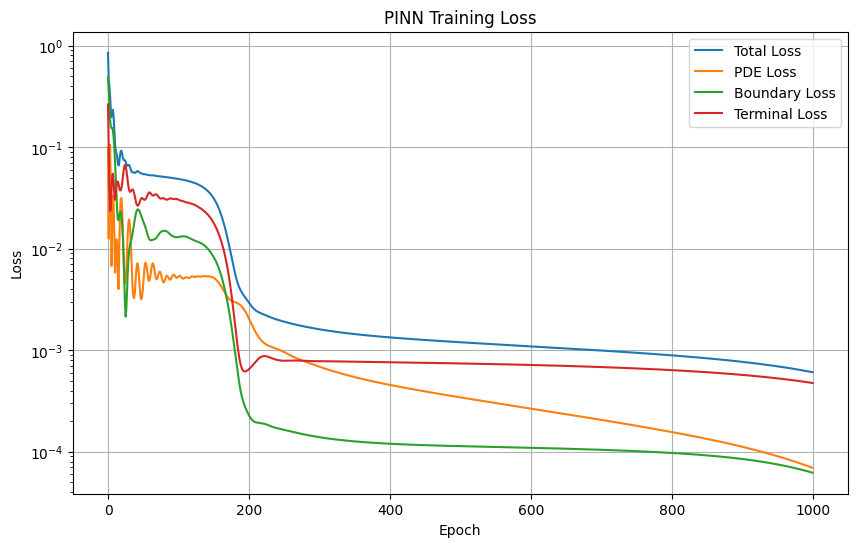

In [ ]:
plt.figure(figsize=(10, 6))

plt.semilogy(
    loss_history,
    label="Total Loss"
)

plt.semilogy(
    pde_history,
    label="PDE Loss"
)

plt.semilogy(
    boundary_history,
    label="Boundary Loss"
)

plt.semilogy(
    terminal_history,
    label="Terminal Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss")
plt.legend()
plt.grid(True)

plt.show()


### Why I used a logarithmic scale for the loss graph

PINN losses often change by several orders of magnitude during training. A logarithmic vertical axis makes both the early large losses and the later small losses visible on the same figure. The graph is used to assess convergence and identify instability or spikes in the optimisation process. Matplotlib is used for the visualisation (Hunter, 2007).


## 14. Evaluate the PINN at the baseline point

The model predicts $u=V/K$, therefore the financial option price is recovered from

$$
V=Ku.
$$


In [ ]:
S_eval = tf.constant(
    [[S0]],
    dtype=tf.float32
)

t_eval = tf.constant(
    [[0.0]],
    dtype=tf.float32
)

u_pred = model_prediction(
    model,
    S_eval,
    t_eval
)

V_pinn_point = K * u_pred

pinn_price = float(
    V_pinn_point.numpy()[0, 0]
)

absolute_point_error = abs(
    pinn_price - analytical_price
)

print(f"PINN Call Price:       {pinn_price:.10f}")
print(f"Analytical Call Price: {analytical_price:.10f}")
print(f"Absolute Error:        {absolute_point_error:.10f}")


PINN Call Price:       12.0647325516
Analytical Call Price: 10.4505835722
Absolute Error:        1.6141489794


## 15. Evaluate the PINN across the asset-price domain at t = 0


In [ ]:
# Evaluation grid
S_eval_np = np.linspace(
    0.0,
    S_max,
    401
).reshape(-1, 1)

t_eval_np = np.zeros_like(
    S_eval_np
)

S_eval_tf = tf.constant(
    S_eval_np,
    dtype=tf.float32
)

t_eval_tf = tf.constant(
    t_eval_np,
    dtype=tf.float32
)

# PINN predicts u = V/K
u_pinn = model_prediction(
    model,
    S_eval_tf,
    t_eval_tf
).numpy().reshape(-1)

# Convert back to actual option prices
V_pinn = K * u_pinn

# Analytical benchmark
V_exact = black_scholes_call(
    S_eval_np.reshape(-1),
    K,
    r,
    sigma,
    T,
    t=0.0
)

# Error
error = V_pinn - V_exact

# Metrics
mse = np.mean(
    error**2
)

rmse = np.sqrt(
    mse
)

l2_error = np.linalg.norm(
    error,
    ord=2
)

print("PINN evaluation metrics at t = 0")
print("--------------------------------")
print(f"MSE:       {mse:.10e}")
print(f"RMSE:      {rmse:.10e}")
print(f"L2 Error:  {l2_error:.10e}")
print(f"Runtime:   {training_time:.6f} seconds")


PINN evaluation metrics at t = 0
--------------------------------
MSE:       1.2663378369e+00
RMSE:      1.1253167718e+00
L2 Error:  2.2534450794e+01
Runtime:   189.765311 seconds


## 16. Analytical Black–Scholes vs PINN


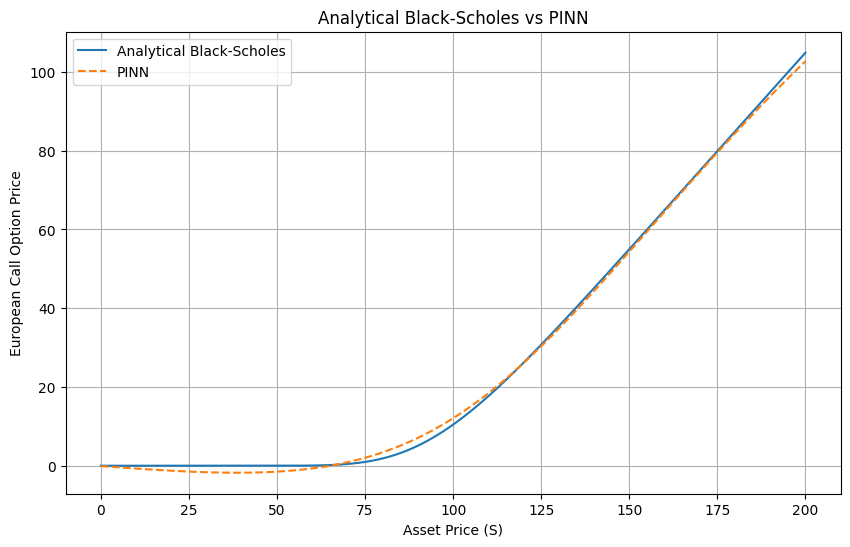

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    S_eval_np.reshape(-1),
    V_exact,
    label="Analytical Black-Scholes"
)

plt.plot(
    S_eval_np.reshape(-1),
    V_pinn,
    "--",
    label="PINN"
)

plt.xlabel("Asset Price (S)")
plt.ylabel("European Call Option Price")
plt.title("Analytical Black-Scholes vs PINN")
plt.legend()
plt.grid(True)

plt.show()


### Why I included this figure

The figure provides a visual comparison that complements the numerical error table. Curves that appear close on an option-price plot may still have materially different numerical errors, so the graphical results are interpreted together with MSE, RMSE, $L_2$ and maximum-error measures.




## 17. PINN error across the asset-price domain


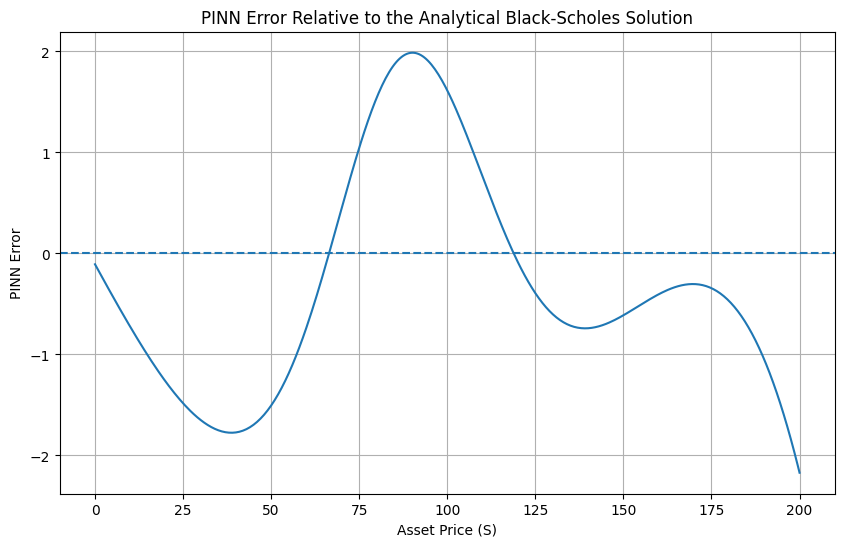

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    S_eval_np.reshape(-1),
    error
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.xlabel("Asset Price (S)")
plt.ylabel("PINN Error")
plt.title("PINN Error Relative to the Analytical Black-Scholes Solution")
plt.grid(True)

plt.show()


### Why I included this figure

The figure provides a visual comparison that complements the numerical error table. Curves that appear close on an option-price plot may still have materially different numerical errors, so the graphical results are interpreted together with MSE, RMSE, $L_2$ and maximum-error measures.




## 18. Summary table for the baseline PINN experiment


In [ ]:
summary = pd.DataFrame({
    "Method": ["PINN"],
    "Price at S=100": [pinn_price],
    "Analytical Price": [analytical_price],
    "Absolute Price Error": [absolute_point_error],
    "MSE": [mse],
    "RMSE": [rmse],
    "L2 Error": [l2_error],
    "Training Runtime (s)": [training_time]
})

summary


,Method,Price at S=100,Analytical Price,Absolute Price Error,MSE,RMSE,L2 Error,Training Runtime (s)
0,PINN,12.064733,10.450584,1.614149,1.266338,1.125317,22.534451,189.765311


### Why I stored the results in a DataFrame

A pandas DataFrame is used to keep prices, errors, runtimes and model settings in a structured table. This makes it easier to compare methods consistently, export results, and reproduce the tables (McKinney, 2010).

The DataFrame does not perform the numerical method itself; it organises outputs already produced by the analytical, FDM or PINN calculations.


## 19. Optional: PINN solution over the full (S,t) domain


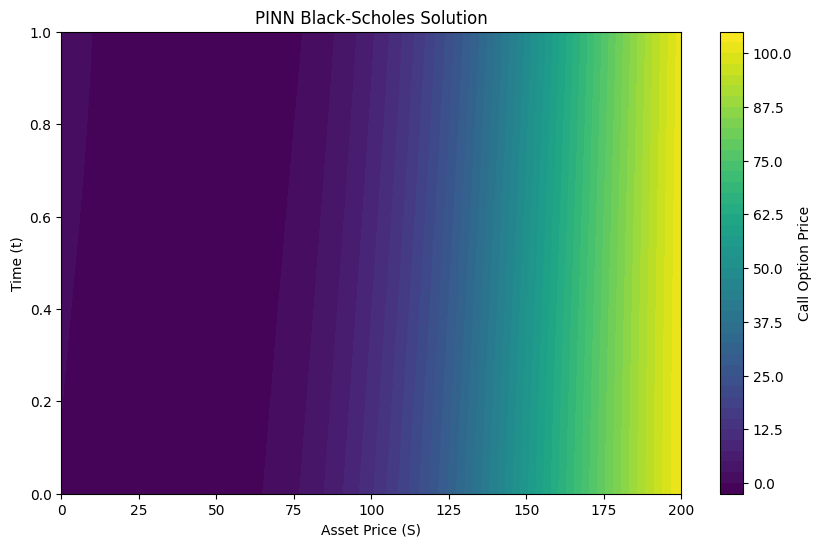

In [ ]:
# Grid for the full PINN solution
S_surface = np.linspace(
    0.0,
    S_max,
    200
)

t_surface = np.linspace(
    0.0,
    T,
    100
)

S_mesh, t_mesh = np.meshgrid(
    S_surface,
    t_surface
)

S_flat = tf.constant(
    S_mesh.reshape(-1, 1),
    dtype=tf.float32
)

t_flat = tf.constant(
    t_mesh.reshape(-1, 1),
    dtype=tf.float32
)

u_surface = model_prediction(
    model,
    S_flat,
    t_flat
).numpy().reshape(
    t_mesh.shape
)

V_surface = K * u_surface

plt.figure(figsize=(10, 6))

contour = plt.contourf(
    S_mesh,
    t_mesh,
    V_surface,
    levels=50
)

plt.colorbar(
    contour,
    label="Call Option Price"
)

plt.xlabel("Asset Price (S)")
plt.ylabel("Time (t)")
plt.title("PINN Black-Scholes Solution")

plt.show()


### Why I included this figure

The figure provides a visual comparison that complements the numerical error table. Curves that appear close on an option-price plot may still have materially different numerical errors, so the graphical results are interpreted together with MSE, RMSE, $L_2$ and maximum-error measures.



## 20. Optional: analytical-vs-PINN absolute error over the full domain


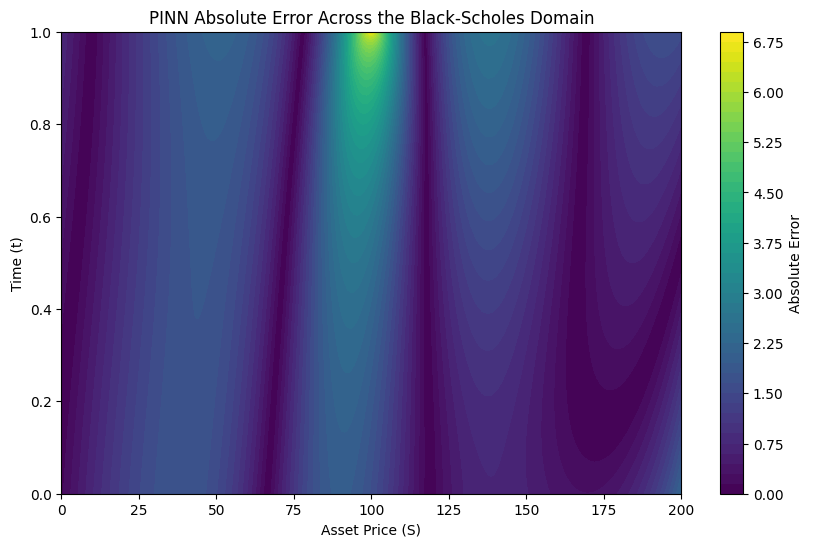

In [ ]:
# Analytical solution over the same mesh
V_exact_surface = np.zeros_like(
    S_mesh,
    dtype=float
)

for j, t_value in enumerate(t_surface):
    V_exact_surface[j, :] = black_scholes_call(
        S_surface,
        K,
        r,
        sigma,
        T,
        t=float(t_value)
    )

absolute_error_surface = np.abs(
    V_surface - V_exact_surface
)

plt.figure(figsize=(10, 6))

contour = plt.contourf(
    S_mesh,
    t_mesh,
    absolute_error_surface,
    levels=50
)

plt.colorbar(
    contour,
    label="Absolute Error"
)

plt.xlabel("Asset Price (S)")
plt.ylabel("Time (t)")
plt.title("PINN Absolute Error Across the Black-Scholes Domain")

plt.show()


### Why I included this figure

The figure provides a visual comparison that complements the numerical error table. Curves that appear close on an option-price plot may still have materially different numerical errors, so the graphical results are interpreted together with MSE, RMSE, $L_2$ and maximum-error measures.



## 21. What I learned from the 1,000-epoch diagnostic run

The 1,000-epoch run showed that the normalised PINN was learning, but the pricing error was still too large for it to be used as the final model. I therefore kept the same basic PINN formulation and increased the training length in the next experiment.

This diagnostic stage was useful because it showed that the code and loss functions were working before I spent more computation time on a longer run.




## References


- Black, F. and Scholes, M. (1973) ‘The pricing of options and corporate liabilities’, *Journal of Political Economy*, 81(3), pp. 637–654.
- Hull, J.C. (2018) *Options, Futures, and Other Derivatives*. 10th edn. Harlow: Pearson.
- Raissi, M., Perdikaris, P. and Karniadakis, G.E. (2019) ‘Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations’, *Journal of Computational Physics*, 378, pp. 686–707. https://doi.org/10.1016/j.jcp.2018.10.045
- Karniadakis, G.E., Kevrekidis, I.G., Lu, L., Perdikaris, P., Wang, S. and Yang, L. (2021) ‘Physics-informed machine learning’, *Nature Reviews Physics*, 3, pp. 422–440. https://doi.org/10.1038/s42254-021-00314-5
- Wang, S., Teng, Y. and Perdikaris, P. (2021) ‘Understanding and mitigating gradient flow pathologies in physics-informed neural networks’, *SIAM Journal on Scientific Computing*, 43(5), pp. A3055–A3081. https://doi.org/10.1137/20M1318043
- TensorFlow, *Introduction to gradients and automatic differentiation*: https://www.tensorflow.org/guide/autodiff



## Results obtained from the completed 1,000-epoch diagnostic run

The normalised PINN diagnostic run produced the following results:

| Measure | Result |
|---|---:|
| Initial total loss | 1.226168 |
| Initial PDE loss | 0.029833 |
| Initial boundary loss | 0.865710 |
| Initial terminal loss | 0.330625 |
| Total loss at epoch 1,000 | $8.921528\times10^{-4}$ |
| PDE loss at epoch 1,000 | $1.210696\times10^{-4}$ |
| Boundary loss at epoch 1,000 | $1.127079\times10^{-4}$ |
| Terminal loss at epoch 1,000 | $6.583753\times10^{-4}$ |
| Training time | 129.917 s |
| PINN price at $S=100,t=0$ | 12.791760 |
| Analytical price | 10.450584 |
| Absolute pricing error | 2.341177 |
| MSE | 2.619151 |
| RMSE | 1.618379 |
| $L_2$ error | 32.408014 |

These results show that normalisation corrected the earlier loss-scale imbalance, because all three loss components decreased. However, 1,000 epochs were not sufficient for accurate pricing. This justified continuing to a longer training experiment rather than treating the diagnostic run as the final PINN result.




## References

Black, F. & Scholes, M. 1973. The pricing of options and corporate liabilities. *Journal of Political Economy*, 81(3):637-654. DOI: 10.1086/260062.

Crank, J. & Nicolson, P. 1947. A practical method for numerical evaluation of solutions of partial differential equations of the heat-conduction type. *Proceedings of the Cambridge Philosophical Society*, 43(1):50-67. DOI: 10.1017/S0305004100023197.

Duffy, D.J. 2006. *Finite difference methods in financial engineering: A partial differential equation approach*. Chichester: John Wiley & Sons. DOI: 10.1002/9781118673447.

Harris, C.R., Millman, K.J., van der Walt, S.J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N.J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M.H., Brett, M., Haldane, A., del Río, J.F., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C. & Oliphant, T.E. 2020. Array programming with NumPy. *Nature*, 585:357-362. DOI: 10.1038/s41586-020-2649-2.

Hull, J.C. 2018. *Options, futures, and other derivatives*. 10th ed. Harlow: Pearson.

Hunter, J.D. 2007. Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3):90-95. DOI: 10.1109/MCSE.2007.55.

Karniadakis, G.E., Kevrekidis, I.G., Lu, L., Perdikaris, P., Wang, S. & Yang, L. 2021. Physics-informed machine learning. *Nature Reviews Physics*, 3(6):422-440. DOI: 10.1038/s42254-021-00314-5.

McKinney, W. 2010. Data structures for statistical computing in Python. In: van der Walt, S. & Millman, J. eds. *Proceedings of the 9th Python in Science Conference*. Austin, TX: SciPy, 56-61. DOI: 10.25080/Majora-92bf1922-00a.

Raissi, M., Perdikaris, P. & Karniadakis, G.E. 2019. Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. *Journal of Computational Physics*, 378:686-707. DOI: 10.1016/j.jcp.2018.10.045.

Virtanen, P., Gommers, R., Oliphant, T.E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S.J., Brett, M., Wilson, J., Millman, K.J., Mayorov, N., Nelson, A.R.J., Jones, E., Kern, R., Larson, E., Carey, C.J., Polat, İ., Feng, Y., Moore, E.W., VanderPlas, J., Laxalde, D., Perktold, J., Cimrman, R., Henriksen, I., Quintero, E.A., Harris, C.R., Archibald, A.M., Ribeiro, A.H., Pedregosa, F., van Mulbregt, P. & SciPy 1.0 Contributors. 2020. SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17:261-272. DOI: 10.1038/s41592-019-0686-2.

Wang, S., Teng, Y. & Perdikaris, P. 2021. Understanding and mitigating gradient flow pathologies in physics-informed neural networks. *SIAM Journal on Scientific Computing*, 43(5):A3055-A3081. DOI: 10.1137/20M1318043.

